In [1]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 50.9 MB/s eta 0:00:00


In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show

In [3]:
cdl_file_path = "2020_30m_cdls_cropped.tif"  # Change this for different years

In [4]:
# Read the CDL raster file
with rasterio.open(cdl_file_path) as src:
    cdl_image = src.read(1)  # Read first band (grayscale values)
    transform = src.transform  # Get transformation info


In [6]:
#Define Grayscale to Label Map
cdl_labels_colors = {
    0: ("Background", (0, 0, 0)),
    1: ("Corn", (255, 255, 0)),
    2: ("Cotton", (255, 192, 203)),
    3: ("Rice", (0, 128, 128)),
    4: ("Sorghum", (255, 165, 0)),
    5: ("Soybeans", (34, 139, 34)),
    6: ("Sunflower", (255, 215, 0)),
    10: ("Peanuts", (205, 133, 63)),
    12: ("Tobacco", (139, 69, 19)),
    14: ("Sweet Corn", (255, 255, 153)),
    21: ("Barley", (189, 183, 107)),
    24: ("Winter Wheat", (154, 205, 50)),
    36: ("Alfalfa", (50, 205, 50)),
    37: ("Other Hay/Non Alfalfa", (85, 107, 47)),
    41: ("Forest", (34, 139, 34)),
    42: ("Deciduous Forest", (0, 100, 0)),
    43: ("Evergreen Forest", (0, 128, 0)),
    46: ("Shrubland", (128, 128, 0)),
    49: ("Grassland/Pasture", (107, 142, 35)),
    52: ("Woody Wetlands", (0, 255, 255)),
    53: ("Herbaceous Wetlands", (102, 205, 170)),
    58: ("Tundra", (210, 180, 140)),
    59: ("Barren", (128, 128, 128)),
    61: ("Developed/Open Space", (220, 220, 220)),
    71: ("Open Water", (0, 0, 255)),
    72: ("Perennial Ice/Snow", (255, 250, 250)),
    83: ("Urban", (255, 0, 0)),
    87: ("Clouds", (255, 255, 255)),
    205: ("Marshland", (32, 178, 170)),
}


In [7]:
colorized_raster = np.zeros((cdl_image.shape[0], cdl_image.shape[1], 3), dtype=np.uint8)

In [8]:
# Apply color mapping
for value, (label, color) in cdl_labels_colors.items():
    mask = cdl_image == value  # Find pixels matching the value
    colorized_raster[mask] = color  # Assign corresponding color

(-0.5, 2999.5, 1749.5, -0.5)

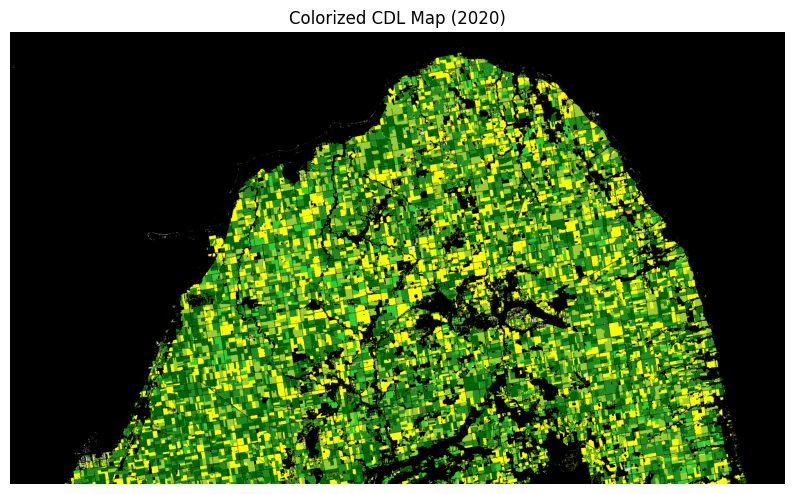

In [17]:
#Display and Save Colorized
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Colorized CDL Map (2020)")
ax.imshow(colorized_raster)
ax.axis("off")  # Hide axes


In [18]:
# Save output image
plt.savefig("cdl_2020_colorized.png", dpi=300)
plt.show()

print("Colorized CDL map saved as 'cdl_2020_colorized.png'.")


<Figure size 640x480 with 0 Axes>

Colorized CDL map saved as 'cdl_2020_colorized.png'.


In [19]:
#Overlay with Vector Map
from PIL import Image

# Load vector map (Ensure it's aligned with the raster)
vector_map_path = "/content/huron_county_full_vector_map.png"
vector_map = Image.open(vector_map_path)

In [20]:
# Resize vector map to match raster dimensions
vector_map = vector_map.resize((cdl_image.shape[1], cdl_image.shape[0]))

Colorized Raster Shape: (1750, 3000, 3)
Vector Overlay Shape: (1750, 3000, 3)


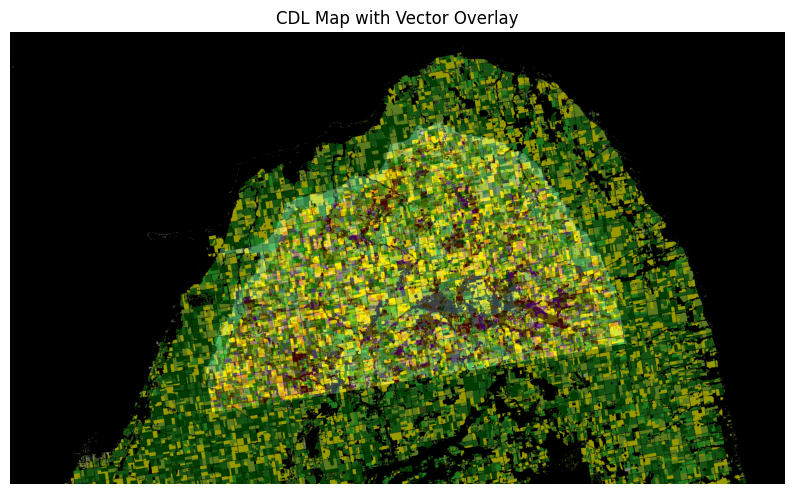

Overlayed CDL map saved as 'cdl_vector_overlay.png'.


In [22]:
# Convert vector map to numpy array and remove the alpha channel (if present)
vector_overlay = np.array(vector_map)[..., :3]  # Keep only RGB channels

# Ensure both images have the same shape
print("Colorized Raster Shape:", colorized_raster.shape)  # Should be (1750, 3000, 3)
print("Vector Overlay Shape:", vector_overlay.shape)  # Should be (1750, 3000, 3) now

# Blend images (Weighted overlay)
blended = (0.6 * colorized_raster + 0.4 * vector_overlay).astype(np.uint8)

# Display the blended image
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("CDL Map with Vector Overlay")
plt.imshow(blended)
plt.axis("off")
plt.show()

# Save the overlay result
plt.imsave("cdl_vector_overlay.png", blended)

print("Overlayed CDL map saved as 'cdl_vector_overlay.png'.")


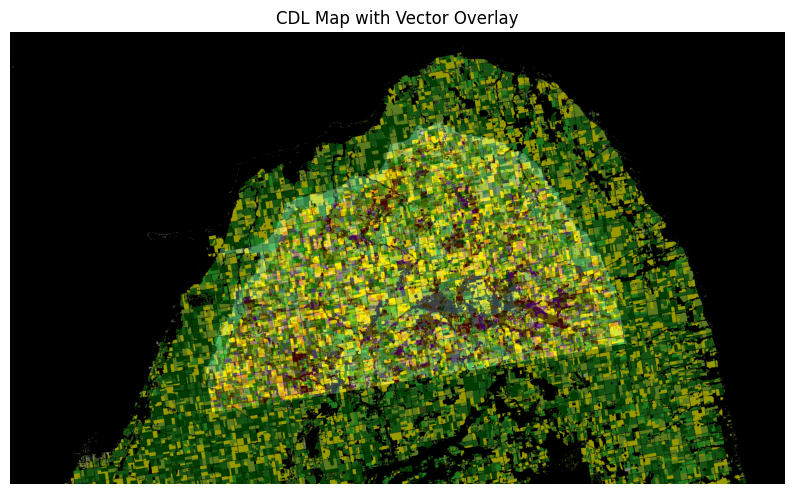

Overlayed CDL map saved as 'cdl_vector_overlay.png'.


In [23]:
# Plot overlay
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("CDL Map with Vector Overlay")
plt.imshow(blended)
plt.axis("off")
plt.show()

# Save overlay result
plt.imsave("cdl_vector_overlay.png", blended)

print("Overlayed CDL map saved as 'cdl_vector_overlay.png'.")